# MLP - XOR Problem

## الترتيب / Flow
1. استيراد المكتبات - Import libraries
2. قراءة البيانات - Load dataset
3. تجهيز `X` و `y` - Prepare features and target
4. تقسيم البيانات - Train/Test split
5. Feature scaling - Standardization
6. Perceptron خطي (طبقة واحدة) - Linear perceptron baseline
7. MLP (طبقة مخفية + ReLU) - Multi-layer perceptron
8. مقارنة الدقة - Compare accuracy
9. رسم حدود القرار - Decision boundary plot

In [1]:
# Step 1) استيراد المكتبات / Import libraries
# pip install tensorflow -q  # uncomment in Colab if needed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# Step 2) قراءة البيانات / Load dataset
dataset = pd.read_csv('XOR.csv')
dataset.head()

,x1,x2,label
0,0.045708,-0.155998,0
1,0.112568,0.141085,0
2,-0.292655,-0.195327,0
3,0.019176,-0.047436,0
4,-0.002520,-0.127957,0


In [3]:
# Step 3) تجهيز X و y / Prepare features and target
X = dataset[['x1', 'x2']].values
y = dataset['label'].values

In [4]:
# Step 4) تقسيم البيانات / Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [5]:
# Step 5) Feature scaling / Standardization
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [6]:
# Step 6) Perceptron خطي - طبقة واحدة / Linear perceptron (single layer)
perceptron = Sequential([
    Dense(units=1, activation='sigmoid', input_shape=(2,))
])
perceptron.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
perceptron.fit(X_train, y_train, batch_size=16, epochs=100, verbose=0)
perceptron_loss, perceptron_acc = perceptron.evaluate(X_test, y_test, verbose=0)
print(f'Perceptron test accuracy: {perceptron_acc:.2f}')

C:\Users\A7MED\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Perceptron test accuracy: 0.57


In [7]:
# Step 7) MLP - طبقة مخفية + ReLU / Hidden layer + ReLU
mlp = Sequential([
    Dense(units=8, activation='relu', input_shape=(2,)),
    Dense(units=1, activation='sigmoid')
])
mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp.fit(X_train, y_train, batch_size=16, epochs=100, verbose=0)
mlp_loss, mlp_acc = mlp.evaluate(X_test, y_test, verbose=0)
print(f'MLP test accuracy: {mlp_acc:.2f}')

MLP test accuracy: 1.00


In [8]:
# Step 8) مقارنة الدقة / Compare accuracy
print('--- XOR Results ---')
print(f'Linear Perceptron: {perceptron_acc:.2%}')
print(f'MLP (hidden layer):  {mlp_acc:.2%}')
print('XOR is not linearly separable — MLP should outperform a single layer.')

--- XOR Results ---
Linear Perceptron: 57.50%
MLP (hidden layer):  100.00%
XOR is not linearly separable — MLP should outperform a single layer.


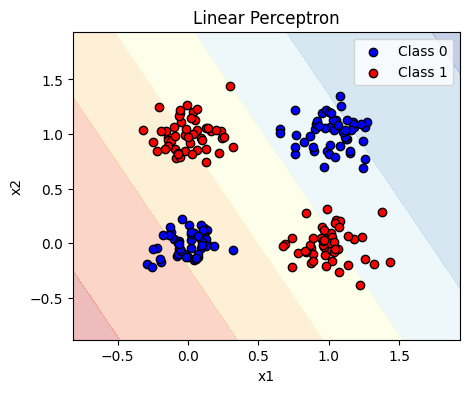

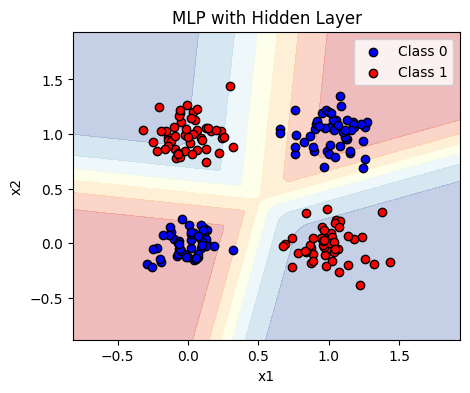

In [9]:
# Step 9) رسم حدود القرار / Decision boundary plot
def plot_decision_boundary(model, title, X_scaled, y_raw, scaler):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    Z = model.predict(grid_scaled, verbose=0).reshape(xx.shape)

    plt.figure(figsize=(5, 4))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    plt.scatter(X[y_raw == 0, 0], X[y_raw == 0, 1], c='blue', edgecolors='k', label='Class 0')
    plt.scatter(X[y_raw == 1, 0], X[y_raw == 1, 1], c='red', edgecolors='k', label='Class 1')
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.show()

plot_decision_boundary(perceptron, 'Linear Perceptron', X_train, y, sc)
plot_decision_boundary(mlp, 'MLP with Hidden Layer', X_train, y, sc)